support vactor regressor

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 

import warnings 
warnings.filterwarnings('ignore')

In [3]:
from sklearn.datasets import make_regression
x,y = make_regression(n_samples=1000, n_features=2, n_targets=1, noise=3.0)

In [4]:
x

array([[ 0.84444597,  1.00742867],
       [-0.21988455, -0.55590719],
       [ 0.32968098, -1.40106191],
       ...,
       [-0.14481929, -1.42127982],
       [ 0.01662136,  0.33042469],
       [-0.26178069,  0.50166381]])

In [5]:
y

array([ 8.04423777e+01, -3.45608341e+01, -1.33434701e+01,  6.53013588e+01,
       -1.74292715e+01, -1.19524329e+02,  2.53404674e+01, -1.96174811e+01,
        2.76633613e+01, -1.80819901e+01,  1.46887877e+02, -1.53689431e+01,
       -1.49082772e+02, -2.52639888e+01, -2.41564524e+01, -3.86316911e+01,
       -8.39616457e+01, -2.47280307e+01, -5.21687249e-01, -1.08228526e+02,
       -5.09174808e+01,  1.03960760e+02, -2.80185872e+00,  8.72751309e+01,
        3.44786848e+01,  7.18447664e+01,  2.20328337e+01, -4.71902915e+01,
        8.76952592e+00, -3.88197507e+01,  9.14850159e+01, -8.01142826e+01,
        2.32172785e+01,  8.23597477e+01, -3.69224309e+00, -1.23938147e+02,
        7.18198726e+00, -1.54389256e+01,  1.05234074e+02,  1.29384386e+02,
        1.06854226e+01, -1.37130094e+02,  4.78918847e+01, -1.96654025e+01,
        8.50190120e+01, -3.13581457e+01, -8.38075047e+01, -1.18706246e+02,
       -1.01974601e+01, -1.03117942e+02,  5.35549015e+01,  9.85681183e+01,
        6.85038865e+01,  

<Axes: xlabel='0', ylabel='1'>

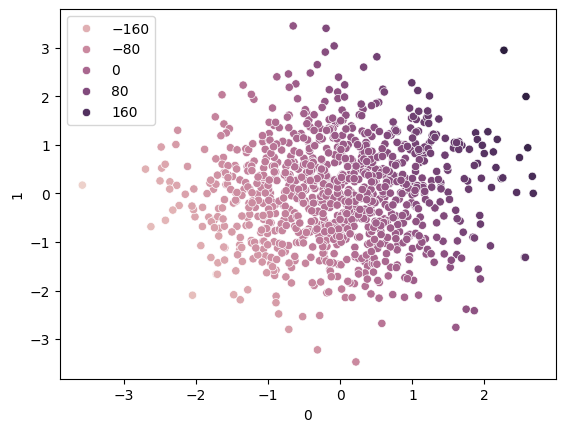

In [6]:
sns.scatterplot(x=pd.DataFrame(x)[0], y=pd.DataFrame(x)[1], hue=y)

In [7]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=1)

In [8]:
x_train.shape

(700, 2)

In [9]:
x_test.shape

(300, 2)

In [10]:
# model training 

from sklearn.svm import SVR

In [14]:
svr = SVR(kernel='linear')

In [15]:
svr.fit(x_train, y_train)

SVR(kernel='linear')

In [16]:
svr.coef_

array([[63.57540331, 26.46510977]])

In [17]:
y_pred = svr.predict(x_test)

In [18]:
y_pred

array([-2.29267348e+00, -2.19915687e+00, -1.75947275e+01,  4.69419037e+01,
       -2.77992692e+01, -2.82538926e+01,  9.20632311e+01, -8.83689076e+01,
        1.57558883e+02, -1.05448672e+02,  1.24463603e+02,  5.90261131e+01,
       -4.38021729e+01, -3.49403216e+01, -3.78657865e+01,  1.07449319e+02,
       -9.14972668e+01,  2.55029314e+01,  1.27018014e+01, -1.31425622e+02,
       -4.89548061e+01,  1.51328239e+02,  2.28356700e+01, -1.38300349e+02,
        8.40642835e+01, -4.36386626e+01, -2.86762181e+01,  7.64585502e+00,
        2.23683903e+01, -8.93983197e+00,  2.15702316e+01, -1.55088905e+01,
       -5.05894512e+01, -1.37766960e+00, -2.40172419e+01,  3.15279710e+01,
       -7.31577199e+01,  6.04839827e+01, -6.73135362e+01, -7.05129902e+00,
        1.30231317e+02,  4.67090455e+01, -3.30748010e+01, -9.96736843e-02,
        4.14288707e+01,  9.16939061e+01, -1.00774186e+02, -1.39657143e+02,
       -3.32871986e+01,  5.04844755e+00,  1.55170923e+01, -4.01339320e+00,
        8.05941517e+01, -

In [21]:
from sklearn.metrics import r2_score

print(r2_score(y_test, y_pred))


0.998328142700547


In [23]:
# hyper parameter tuning 

from sklearn.model_selection import GridSearchCV

parms = {'C':[1,2,3,10,50,100],
          'gamma' : [0.1, 0.2, 1, 2, 3,  0.001, 0.003],
          'kernel' : ['linear'],
          'epsilon' : [0.01, 0.1, 0.2, 0.3]}

grid = GridSearchCV(SVR(), param_grid=parms, cv= 5, verbose=True)

In [24]:
grid.fit(x_train, y_train)

Fitting 5 folds for each of 168 candidates, totalling 840 fits


GridSearchCV(cv=5, estimator=SVR(),
             param_grid={'C': [1, 2, 3, 10, 50, 100],
                         'epsilon': [0.01, 0.1, 0.2, 0.3],
                         'gamma': [0.1, 0.2, 1, 2, 3, 0.001, 0.003],
                         'kernel': ['linear']},
             verbose=True)

In [25]:
grid.best_params_

{'C': 100, 'epsilon': 0.3, 'gamma': 0.1, 'kernel': 'linear'}

In [26]:
grid.best_score_

np.float64(0.9978381899496952)

In [28]:
y_pred = grid.predict(x_test)

In [29]:
print(r2_score(y_test, y_pred))

0.9983710531254434
